# World Happiness Index Prediction

## Load Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans

## Data Extraction

In [4]:
path = "data"
dataset_list = os.listdir(path)
print(dataset_list)

['2015.csv', '2016.csv', '2017.csv', '2018.csv', '2019.csv']


In [5]:
datasets = [pd.read_csv(path + "/" + dataset) for dataset in dataset_list]
df_2015, df_2016, df_2017, df_2018, df_2019 = datasets

##  Initial EDA

In [6]:
df_2015.head()

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


In [7]:
df_2015.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        158 non-null    object 
 1   Region                         158 non-null    object 
 2   Happiness Rank                 158 non-null    int64  
 3   Happiness Score                158 non-null    float64
 4   Standard Error                 158 non-null    float64
 5   Economy (GDP per Capita)       158 non-null    float64
 6   Family                         158 non-null    float64
 7   Health (Life Expectancy)       158 non-null    float64
 8   Freedom                        158 non-null    float64
 9   Trust (Government Corruption)  158 non-null    float64
 10  Generosity                     158 non-null    float64
 11  Dystopia Residual              158 non-null    float64
dtypes: float64(9), int64(1), object(2)
memory usage: 1

In [8]:
for year, data in zip(range(2015,2020), datasets) :
    print(f'{year}     Column: {data.shape[1]}     Row: {data.shape[0]}')

2015     Column: 12     Row: 158
2016     Column: 13     Row: 157
2017     Column: 12     Row: 155
2018     Column: 9     Row: 156
2019     Column: 9     Row: 156


In [9]:
for data in datasets:
    data.columns = data.columns.str.lower()

In [10]:
for year , data in zip(range(2015,2020 ),datasets):
    print(f'{year}\n {data.columns.tolist()}')
    print("--" * 50)

2015
 ['country', 'region', 'happiness rank', 'happiness score', 'standard error', 'economy (gdp per capita)', 'family', 'health (life expectancy)', 'freedom', 'trust (government corruption)', 'generosity', 'dystopia residual']
----------------------------------------------------------------------------------------------------
2016
 ['country', 'region', 'happiness rank', 'happiness score', 'lower confidence interval', 'upper confidence interval', 'economy (gdp per capita)', 'family', 'health (life expectancy)', 'freedom', 'trust (government corruption)', 'generosity', 'dystopia residual']
----------------------------------------------------------------------------------------------------
2017
 ['country', 'happiness.rank', 'happiness.score', 'whisker.high', 'whisker.low', 'economy..gdp.per.capita.', 'family', 'health..life.expectancy.', 'freedom', 'generosity', 'trust..government.corruption.', 'dystopia.residual']
-----------------------------------------------------------------------

In [11]:
column_map = {
    "happiness rank": "happiness_rank",
    "happiness.rank": "happiness_rank",
    "overall rank": "happiness_rank",
    "happiness score": "happiness_score",
    "happiness.score": "happiness_score",
    "score": "happiness_score",
    "economy (gdp per capita)": "gdp_per_capita",
    "economy..gdp.per.capita.": "gdp_per_capita",
    "gdp per capita": "gdp_per_capita",
    "health (life expectancy)": "life_expectancy",
    "health..life.expectancy.": "life_expectancy",
    "healthy life expectancy": "life_expectancy",
    "trust (government corruption)": "government_corruption",
    "trust..government.corruption.": "government_corruption",
    "perceptions of corruption": "government_corruption",
    "family": "family",
    "social support": "family",
    "freedom": "freedom",
    "freedom to make life choices": "freedom",
    "dystopia residual": "dystopia_residual",
    "dystopia.residual": "dystopia_residual",
    "country or region": "country",
    "country": "country",
    "region": "region",
    "generosity": "generosity",
    "standard error": "standard_error",
    "lower confidence interval": "lower_confidence_interval",
    "upper confidence interval": "upper_confidence_interval",
}

for df in datasets:
    df.rename(columns=column_map, inplace=True)

In [12]:
for year, data in zip(range(2015,2020), datasets):
    data["year"] = year

df = pd.concat([df_2015, df_2016, df_2017, df_2018, df_2019], ignore_index= True)

In [13]:
print(f"columns: {df.shape[1]}\nrows: {df.shape[0]}")

columns: 17
rows: 782


In [14]:
df.head()

,country,region,happiness_rank,happiness_score,standard_error,gdp_per_capita,family,life_expectancy,freedom,government_corruption,generosity,dystopia_residual,year,lower_confidence_interval,upper_confidence_interval,whisker.high,whisker.low
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738,2015,NaN,NaN,NaN,NaN
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201,2015,NaN,NaN,NaN,NaN
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204,2015,NaN,NaN,NaN,NaN
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531,2015,NaN,NaN,NaN,NaN
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176,2015,NaN,NaN,NaN,NaN


In [15]:
df.columns

Index(['country', 'region', 'happiness_rank', 'happiness_score',
       'standard_error', 'gdp_per_capita', 'family', 'life_expectancy',
       'freedom', 'government_corruption', 'generosity', 'dystopia_residual',
       'year', 'lower_confidence_interval', 'upper_confidence_interval',
       'whisker.high', 'whisker.low'],
      dtype='object')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   country                    782 non-null    object 
 1   region                     315 non-null    object 
 2   happiness_rank             782 non-null    int64  
 3   happiness_score            782 non-null    float64
 4   standard_error             158 non-null    float64
 5   gdp_per_capita             782 non-null    float64
 6   family                     782 non-null    float64
 7   life_expectancy            782 non-null    float64
 8   freedom                    782 non-null    float64
 9   government_corruption      781 non-null    float64
 10  generosity                 782 non-null    float64
 11  dystopia_residual          470 non-null    float64
 12  year                       782 non-null    int64  
 13  lower_confidence_interval  157 non-null    float64

In [17]:
df.describe().round()

,happiness_rank,happiness_score,standard_error,gdp_per_capita,family,life_expectancy,freedom,government_corruption,generosity,dystopia_residual,year,lower_confidence_interval,upper_confidence_interval,whisker.high,whisker.low
count,782.0,782.0,158.0,782.0,782.0,782.0,782.0,781.0,782.0,470.0,782.0,157.0,157.0,155.0,155.0
mean,79.0,5.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,2.0,2017.0,5.0,5.0,5.0,5.0
std,45.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
min,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015.0,3.0,3.0,3.0,3.0
25%,40.0,5.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,2.0,2016.0,4.0,4.0,5.0,4.0
50%,79.0,5.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,2.0,2017.0,5.0,5.0,5.0,5.0
75%,118.0,6.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,2.0,2018.0,6.0,6.0,6.0,6.0
max,158.0,8.0,0.0,2.0,2.0,1.0,1.0,1.0,1.0,4.0,2019.0,7.0,8.0,8.0,7.0


## PreProcessing

In [18]:
df.duplicated().sum()

0

In [19]:
for col in df:
    per = df[col].isnull().sum() / df.shape[0] * 100
    print(f'{col}:     {per:.2f}')

country:     0.00
region:     59.72
happiness_rank:     0.00
happiness_score:     0.00
standard_error:     79.80
gdp_per_capita:     0.00
family:     0.00
life_expectancy:     0.00
freedom:     0.00
government_corruption:     0.13
generosity:     0.00
dystopia_residual:     39.90
year:     0.00
lower_confidence_interval:     79.92
upper_confidence_interval:     79.92
whisker.high:     80.18
whisker.low:     80.18


In [20]:
df.drop(columns=["region", "standard_error", "dystopia_residual", "lower_confidence_interval", "upper_confidence_interval",
                 "whisker.high", "whisker.low"], inplace=True, errors="ignore")

In [21]:
df.dropna(subset = ["government_corruption"], inplace=True)

In [22]:
df.head()

,country,happiness_rank,happiness_score,gdp_per_capita,family,life_expectancy,freedom,government_corruption,generosity,year
0,Switzerland,1,7.587,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2015
1,Iceland,2,7.561,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2015
2,Denmark,3,7.527,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2015
3,Norway,4,7.522,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2015
4,Canada,5,7.427,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2015


In [23]:
top_10 = df.sort_values("happiness_score", ascending = False).head(10)
bottom_10 = df.sort_values("happiness_score", ascending = True).head(10)

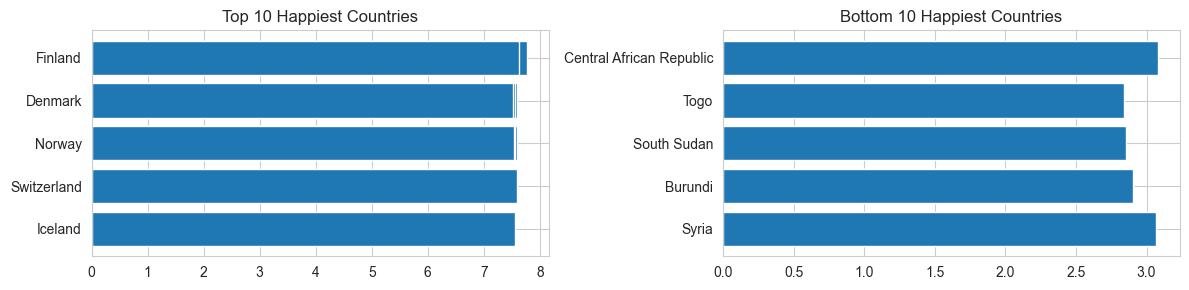

In [24]:
plt.figure(figsize=(12,3))
plt.subplot(121)
plt.barh(top_10["country"], top_10["happiness_score"])
plt.title("Top 10 Happiest Countries")
plt.gca().invert_yaxis()

plt.subplot(122)
plt.barh(bottom_10["country"], bottom_10["happiness_score"])
plt.title("Bottom 10 Happiest Countries")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [25]:
df[df["country"] == "Iran"]

,country,happiness_rank,happiness_score,gdp_per_capita,family,life_expectancy,freedom,government_corruption,generosity,year
109,Iran,110,4.686,1.008800,0.544470,0.698050,0.300330,0.058630,0.380860,2015
262,Iran,105,4.813,1.117580,0.388570,0.642320,0.225440,0.055700,0.385380,2016
422,Iran,108,4.692,1.156873,0.711551,0.639333,0.249323,0.048761,0.387243,2017
575,Iran,106,4.707,1.059000,0.771000,0.691000,0.459000,0.129000,0.282000,2018
742,Iran,117,4.548,1.100000,0.842000,0.785000,0.305000,0.125000,0.270000,2019


In [26]:
print(df.columns[df.columns.duplicated()].tolist())
print(df.index.duplicated().sum())

[]
0


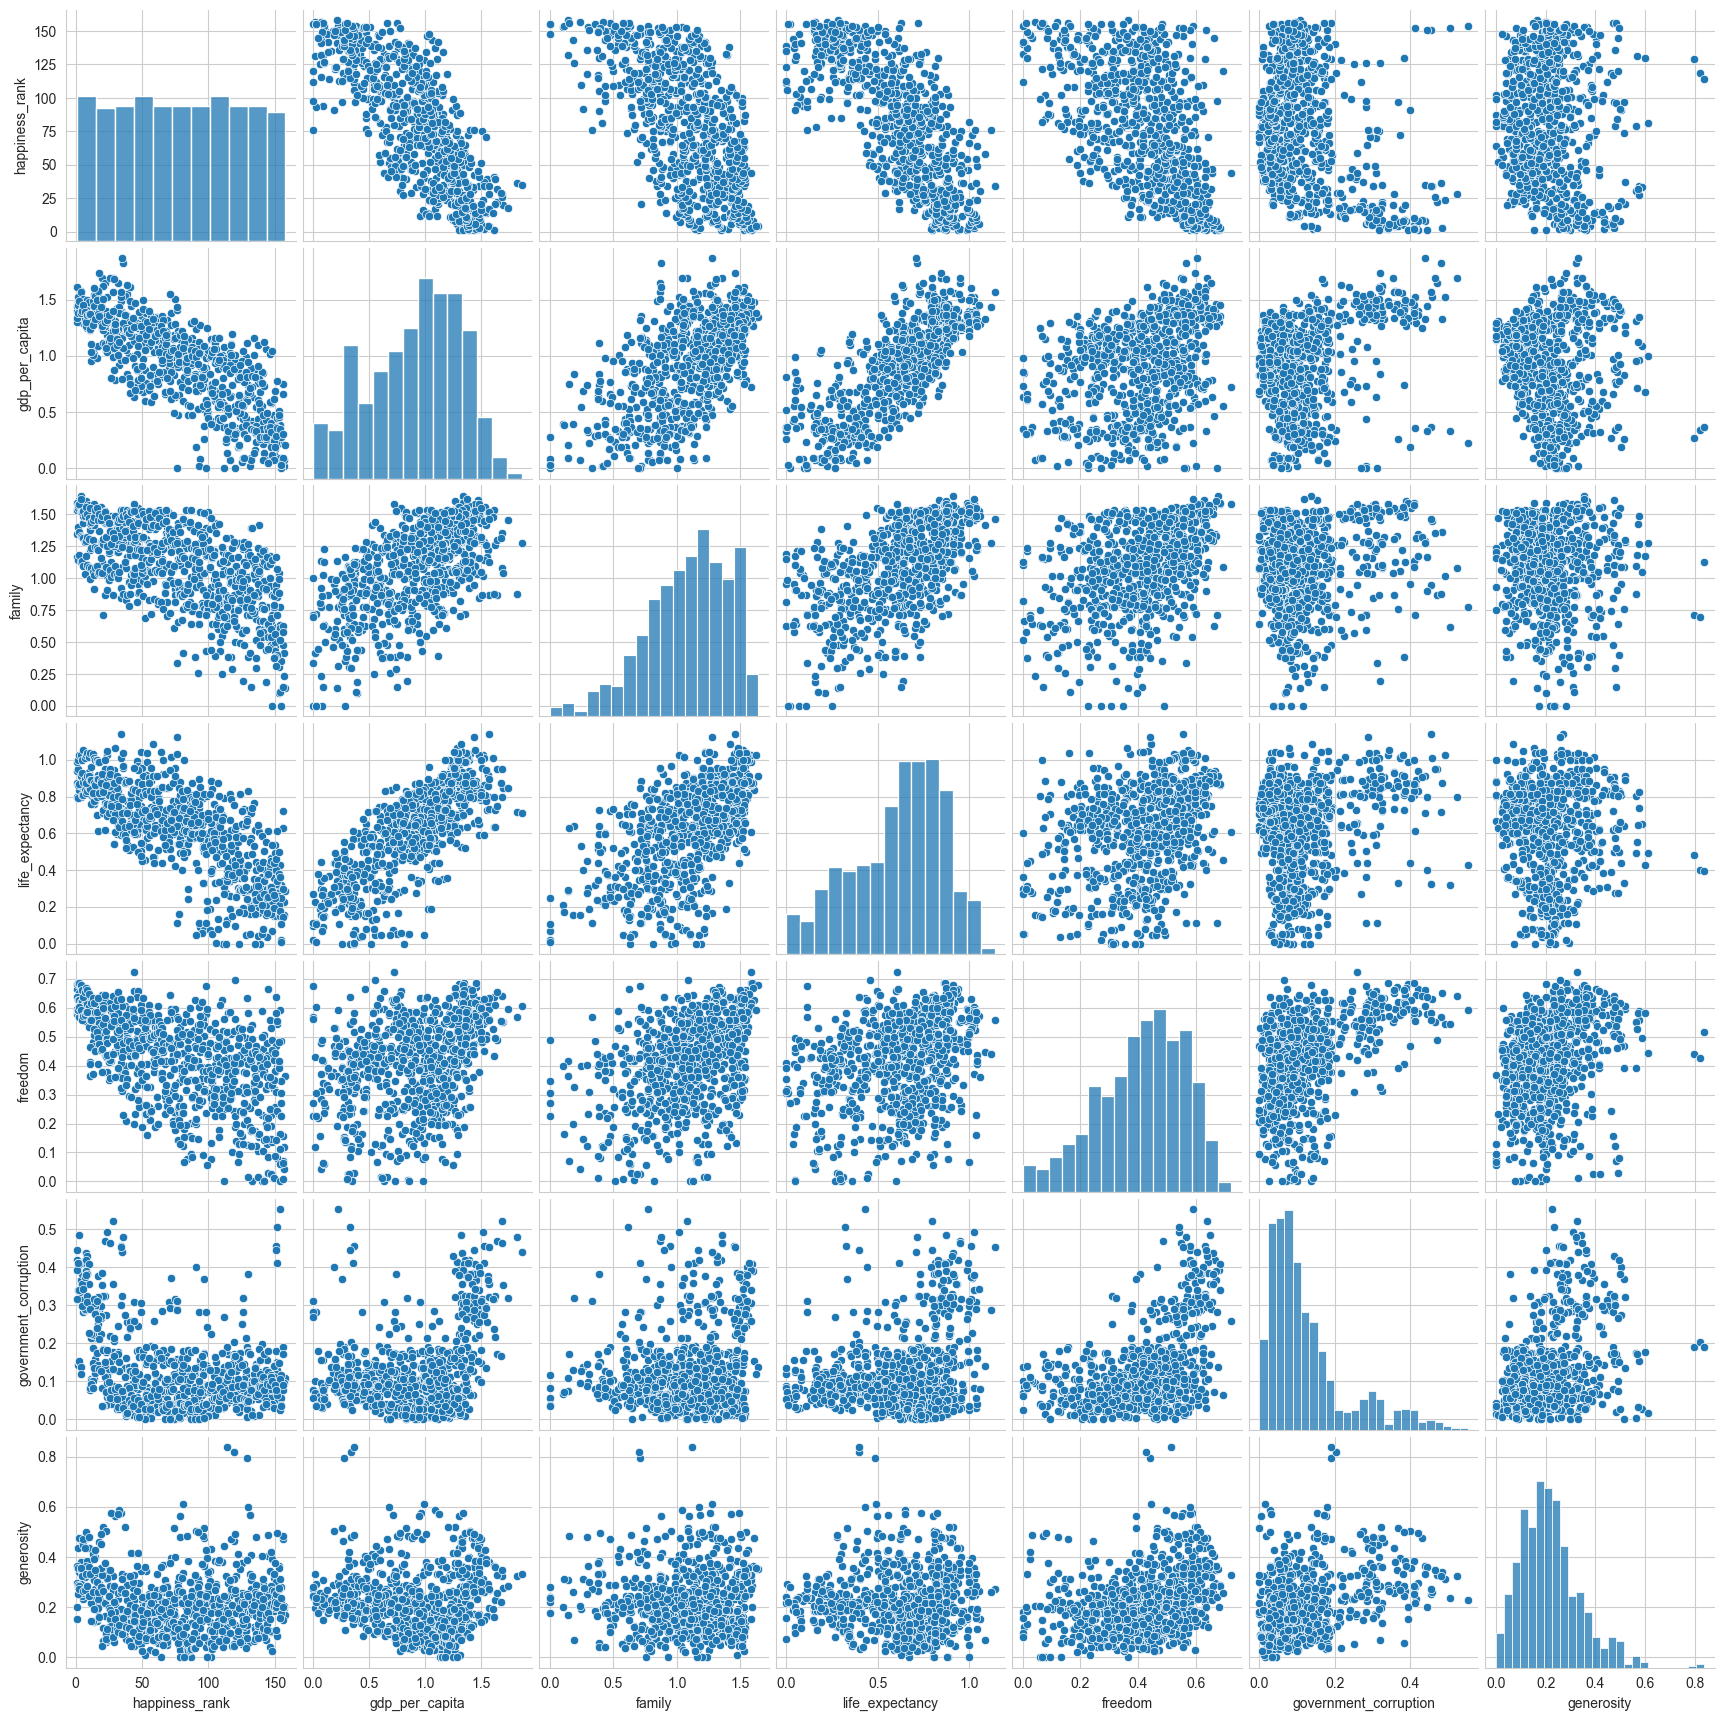

In [27]:
sns.pairplot(df.drop(columns=["country", "happiness_score", "year"]))

<Axes: >

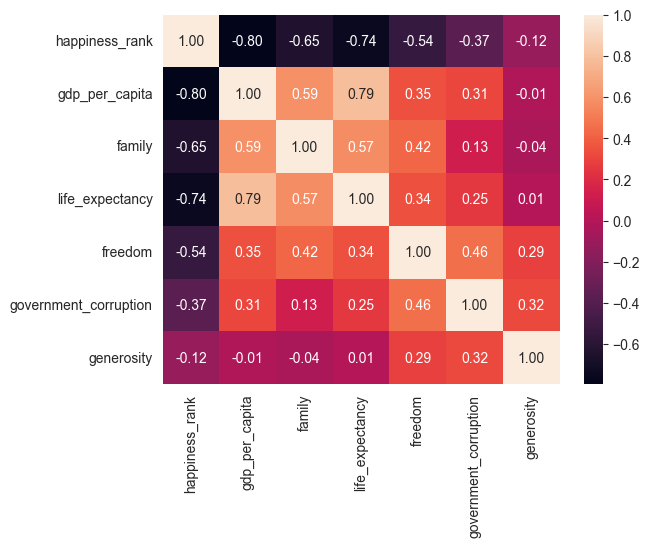

In [28]:
sns.heatmap(df.drop(columns=["country", "happiness_score", "year"]).corr(),annot=True, fmt="0.2f")

In [29]:
df.columns

Index(['country', 'happiness_rank', 'happiness_score', 'gdp_per_capita',
       'family', 'life_expectancy', 'freedom', 'government_corruption',
       'generosity', 'year'],
      dtype='object')

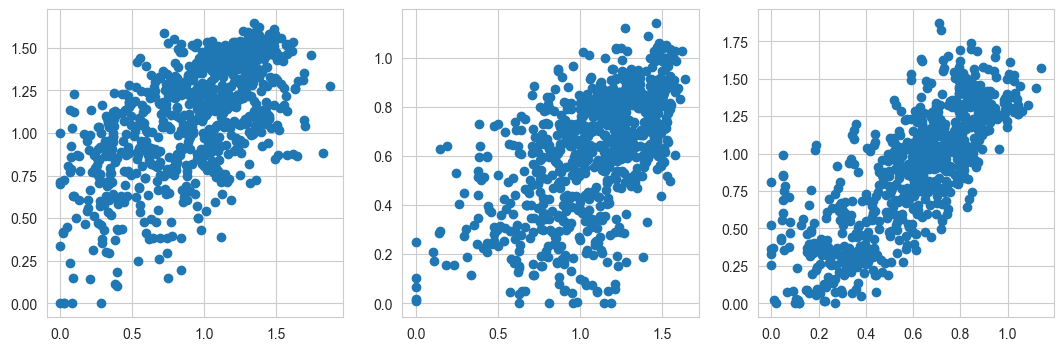

In [30]:
fig, axes= plt.subplots(1,3 , figsize=(13,4))

axes[0].scatter(df["gdp_per_capita"], df["family"])

axes[1].scatter(df["family"], df["life_expectancy"])

axes[2].scatter(df["life_expectancy"], df["gdp_per_capita"])

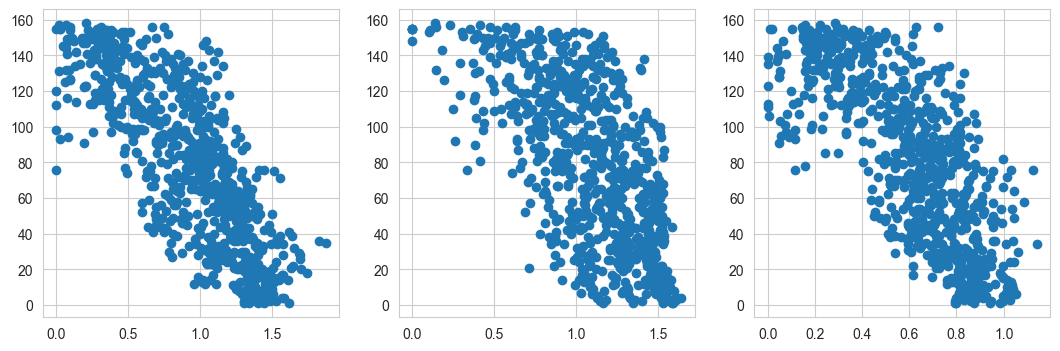

In [31]:
fig, axes= plt.subplots(1,3 , figsize=(13,4))

axes[0].scatter(df["gdp_per_capita"], df["happiness_rank"])

axes[1].scatter(df["family"], df["happiness_rank"])

axes[2].scatter(df["life_expectancy"], df["happiness_rank"])

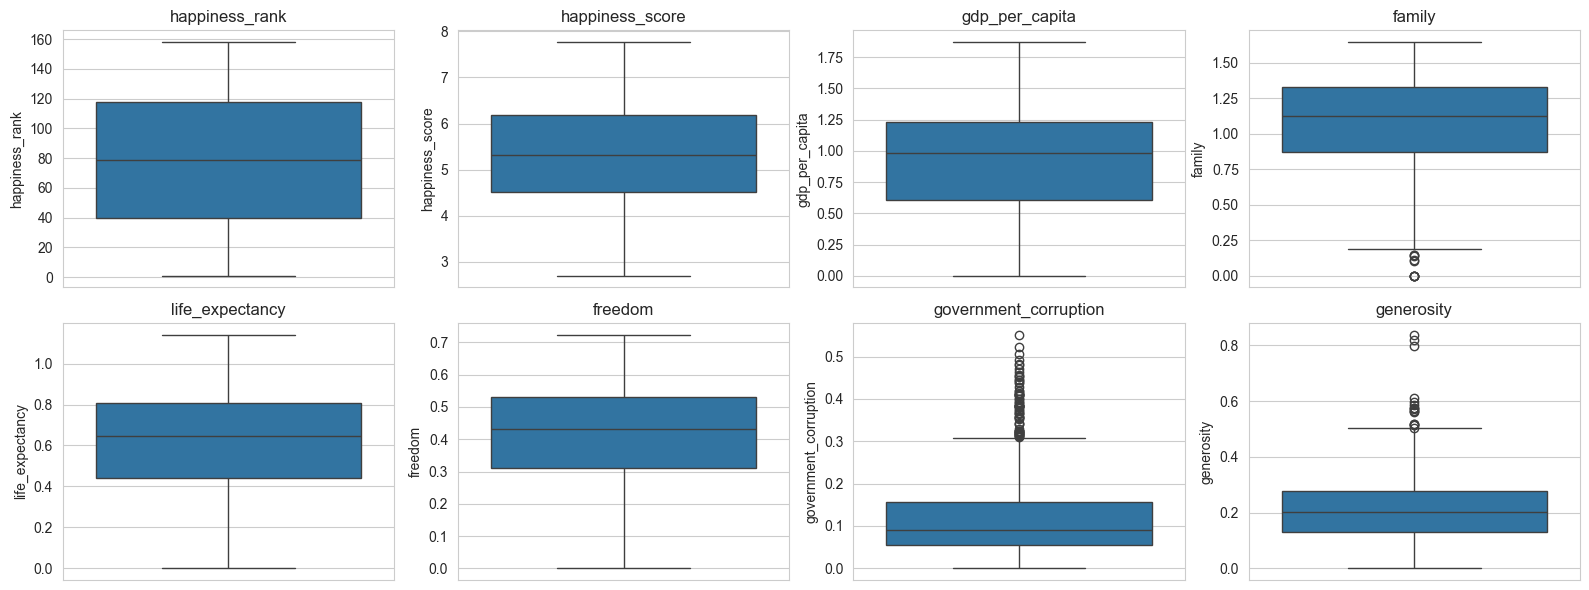

In [32]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, col in zip(axes.flatten(), df.select_dtypes(include='number').columns):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
# plt.savefig("boxplot_jpg")
plt.show()

## Scaling and Normalizing

In [33]:
df.columns

Index(['country', 'happiness_rank', 'happiness_score', 'gdp_per_capita',
       'family', 'life_expectancy', 'freedom', 'government_corruption',
       'generosity', 'year'],
      dtype='object')

In [34]:
feature_cols = ['gdp_per_capita', 'family', 'life_expectancy', 'freedom', 'government_corruption', 'generosity']
X = df[feature_cols].copy()

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

In [35]:
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols, index= X.index)
X_scaled.describe()

,gdp_per_capita,family,life_expectancy,freedom,government_corruption,generosity
count,781.000000,781.000000,781.000000,781.000000,781.000000,781.000000
mean,-0.107298,-0.100964,-0.094845,-0.089545,0.337505,0.111482
std,0.644777,0.719940,0.675271,0.693409,1.037111,0.821103
min,-1.561833,-2.457459,-1.759089,-1.954471,-0.891895,-1.355159
25%,-0.599604,-0.556565,-0.563078,-0.546526,-0.362638,-0.483027
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.400396,0.443435,0.436922,0.453474,0.637362,0.516973
max,1.413547,1.133708,1.341961,1.328678,4.517397,4.267242


## Model Selection

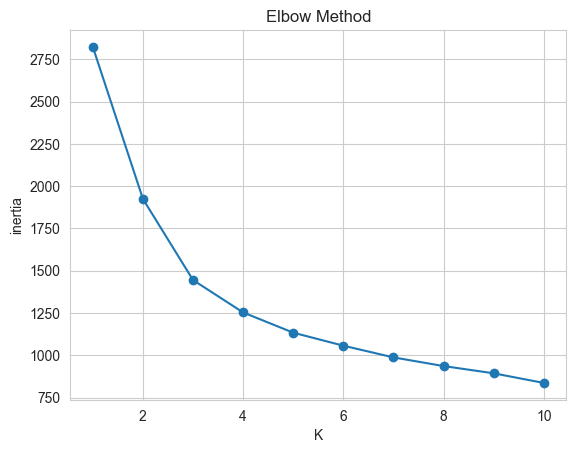

In [36]:
intertias = []
k_range = range(1,11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    intertias.append(km.inertia_)

plt.plot(k_range, intertias, marker='o')
plt.xlabel("K")
plt.ylabel("inertia")
plt.title("Elbow Method")
plt.show()

In [38]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df["cluster"] = kmeans_final.fit_predict(X_scaled)

df.groupby("cluster")[feature_cols].mean()

,gdp_per_capita,family,life_expectancy,freedom,government_corruption,generosity
cluster,,,,,,
0,0.451144,0.749394,0.312911,0.310875,0.098490,0.217682
1,1.063740,1.203096,0.723432,0.385718,0.078688,0.132012
2,0.963041,1.146308,0.665736,0.508720,0.095432,0.363334
3,1.331331,1.289720,0.817784,0.571928,0.338237,0.310597


## Test & Evaluate

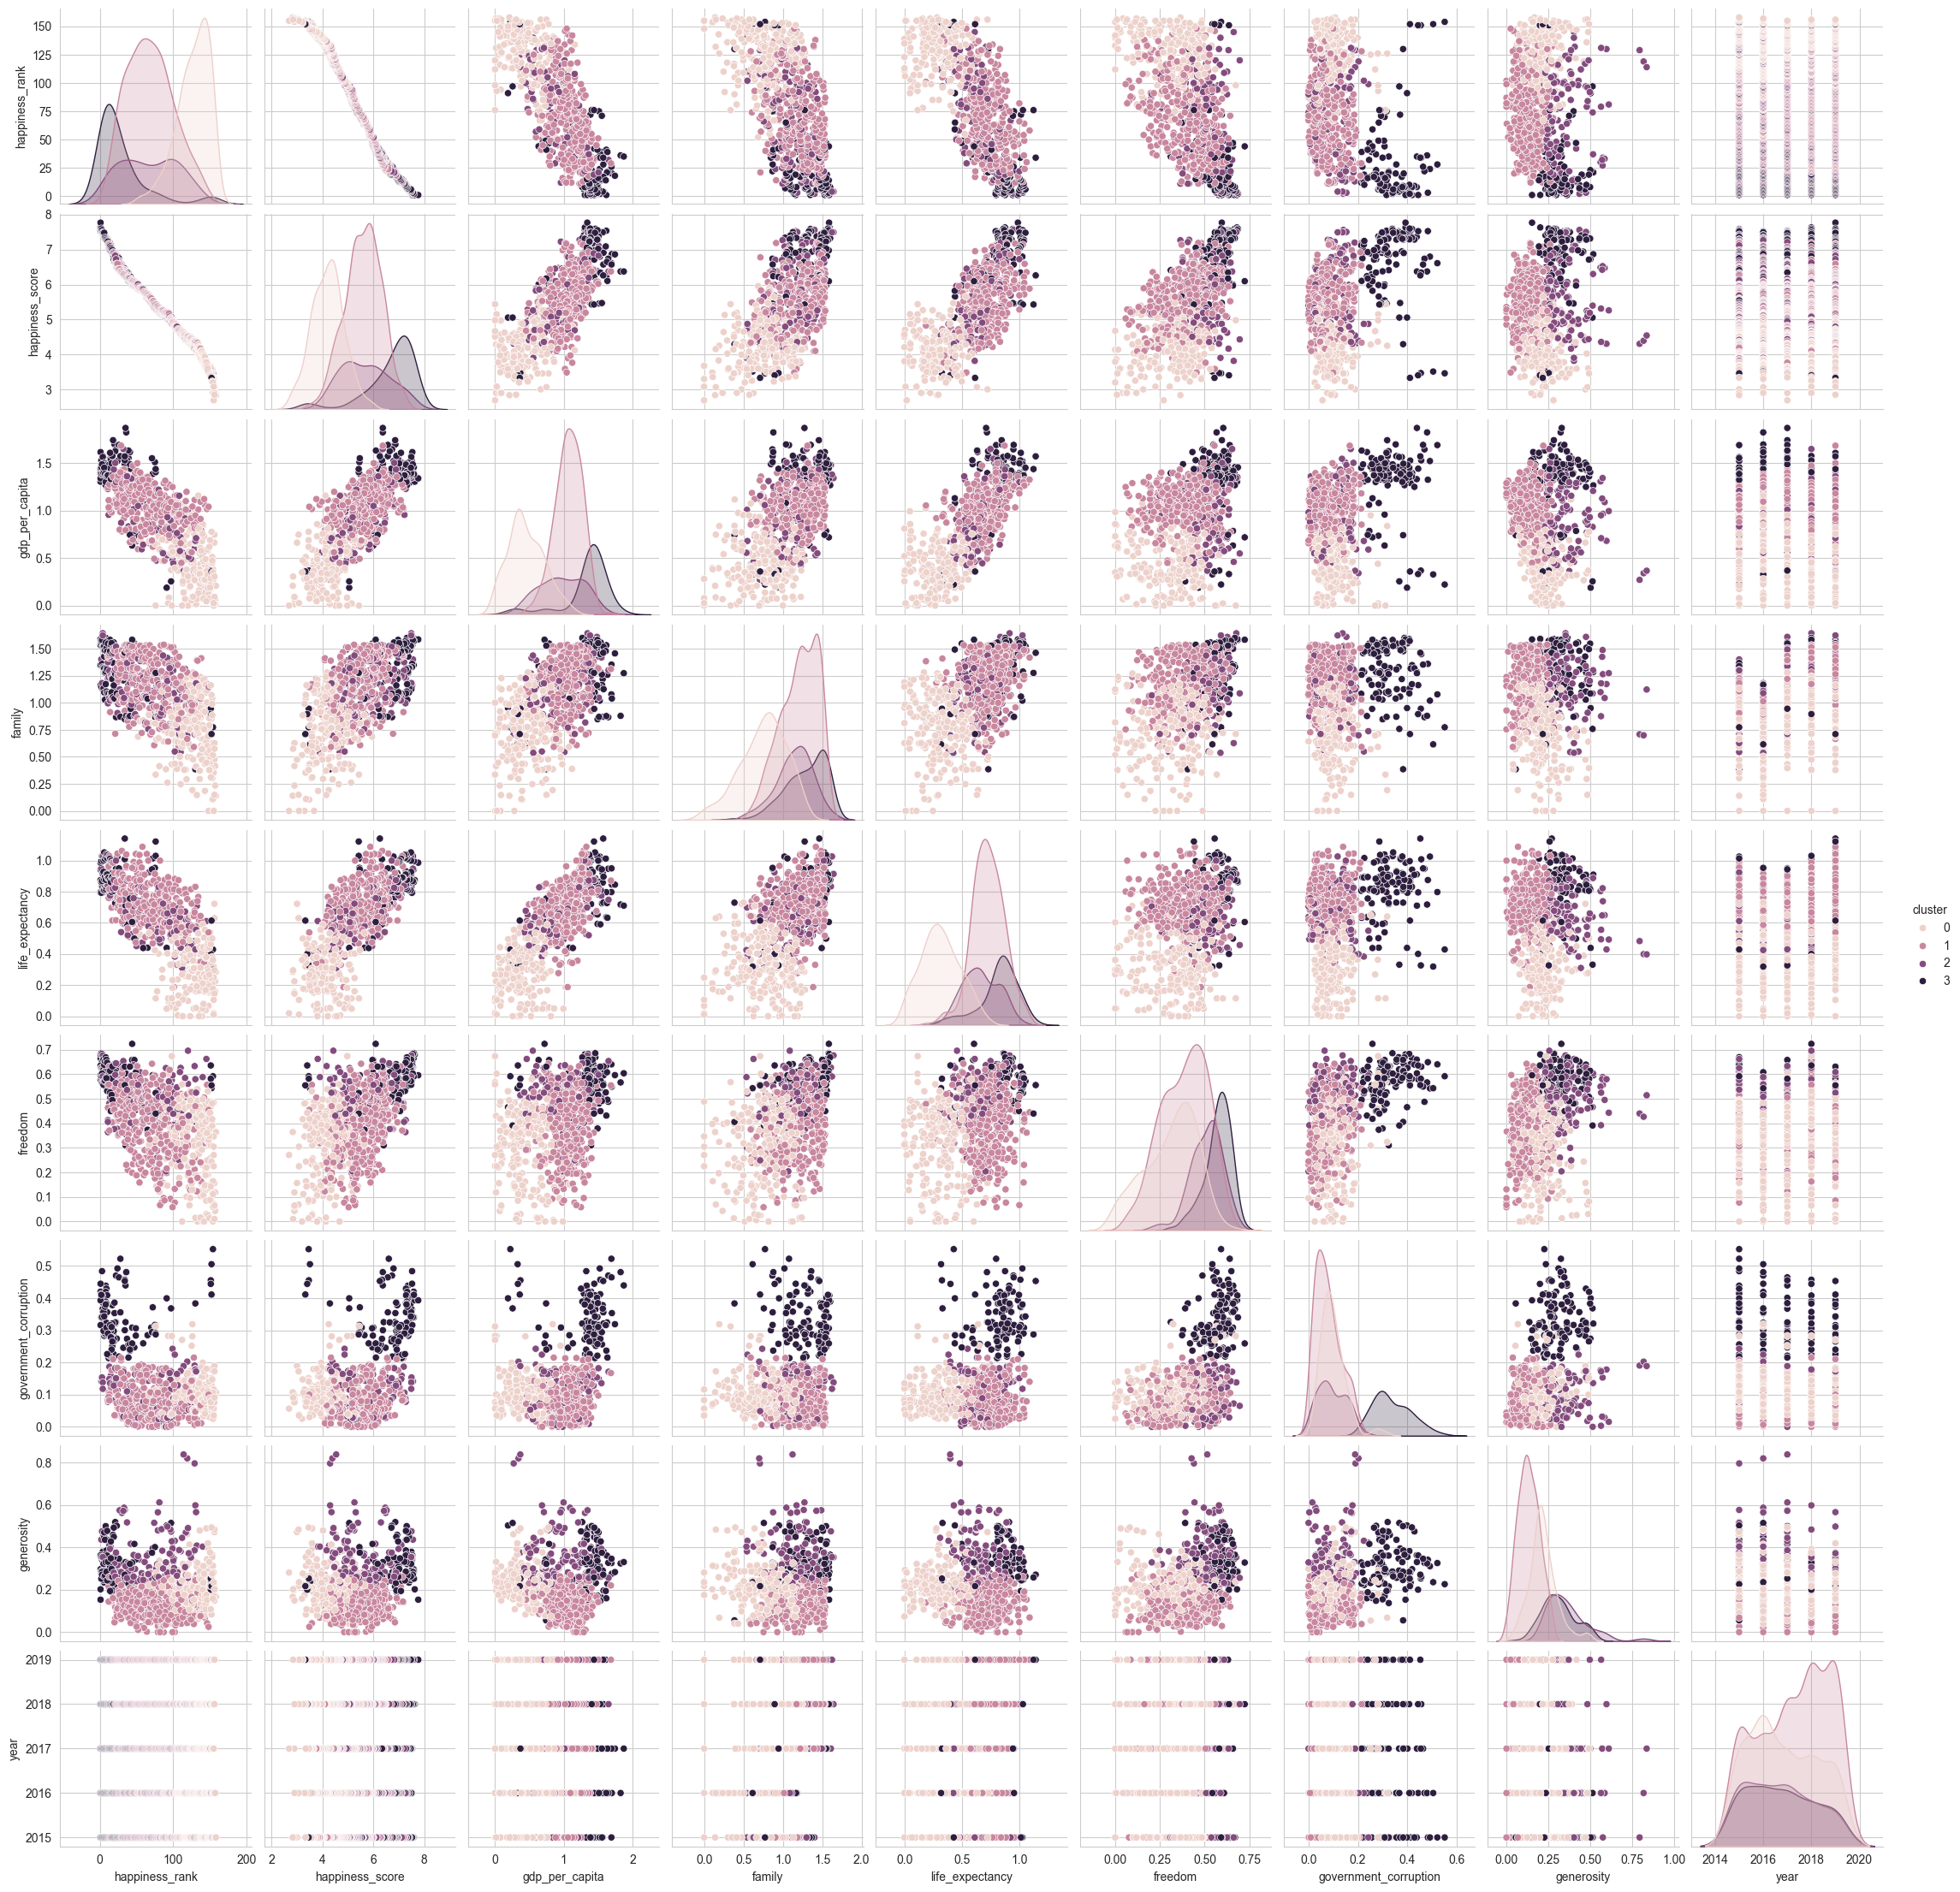

In [39]:
sns.pairplot(df.drop(columns=["country"]), hue="cluster")